In [3]:
import numpy as np
import pandas as pd
import os
import healpy as hp
import matplotlib.pyplot as plt

import os
os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

# Your custom text color
mycolor = 'black'  # or e.g., '#fe9463', (0.996, 0.580, 0.388)
from matplotlib import rcParams
# Global style settings
rcParams.update({
    # Enable LaTeX rendering
    'text.usetex': True,

    # Font settings
    'font.family': 'sans-serif',
    'font.sans-serif': ['Open Sans'],  # Use Open Sans if available

    # Set all text and visual elements to use the custom color
    'text.color': mycolor,
    'axes.labelcolor': mycolor,
    'xtick.color': mycolor,
    'ytick.color': mycolor,
    'axes.edgecolor': mycolor,
    'grid.color': mycolor,
    'legend.edgecolor': mycolor,
    'legend.facecolor': 'none',
    'legend.labelcolor': mycolor,

    # Transparent backgrounds
    'figure.facecolor': 'none',
    'axes.facecolor': 'none',
})

if mycolor=='white':
    rcParams['savefig.transparent'] = True

import matplotlib as mpl
mpl.rcParams['figure.facecolor'] = 'none'
mpl.rcParams['axes.facecolor']   = 'none'
mpl.rcParams['savefig.facecolor'] = 'none'
# fix tick labels size
mpl.rcParams['xtick.labelsize'] = 18
mpl.rcParams['ytick.labelsize'] = 18
mpl.rcParams['axes.labelsize'] = 18
mpl.rcParams['legend.fontsize'] = 18
mpl.rcParams['axes.titlesize'] = 18

In [4]:
user = 'ulyana.dupletsa'

In [5]:
PATH_TO_MAPS = '/Users/' + str(user) + '/Documents/Radio-Sirens/dm_halos_data/'

## Dark matter halo data

The data in `dm_halos_data` containt the number counts of DM halos per each snapshot for a map resolution corresponding to `nside=128`. For our purposes we downgrade the resolution to `nside=16`, which corresponds to $\ell_{\rm max}=48$. The relationship between nside and $\ell_{\rm max}$ is 

$\ell_{\rm max}=3*\text{nside}$

Starting from the DM halo counts, we build the number density contrast maps:

$\text{map}(z, \text{pix}_i) = \frac{N(z, \text{pix}_i)-\bar{N}(z)}{\bar{N}(z)}$

with 

$\bar{N}(z) = \frac{1}{\text{npix}}\sum_i N(z, \text{pix}_i)$

with $\text{npix}$ the total number of pixels given the chosen nside.

In [10]:
###########################################
# Choose the nside value for the maps
###########################################
my_nside = 16

In [11]:
# general settings
lmax         = my_nside * 3
nside_output = my_nside
npix_output  = hp.nside2npix(nside_output)
print(f"nside = {nside_output}, npix = {npix_output}")

nside = 16, npix = 3072


In [8]:
all_sky_degs         = 4 * np.pi * (180 / np.pi)**2
all_sky_degs_per_pix = all_sky_degs/npix_output
print(f"The pixel area given the adopted resolution corresponds to {np.round(all_sky_degs_per_pix, 1)} deg2.")

The pixel area given the adopted resolution corresponds to 13.4 deg2.


In [12]:
count_data = {}
count_map = {}
count_map_out = {}
mean_count_per_pix = {}
zmean_vec = []

np.random.seed(42)
for file in os.listdir(PATH_TO_MAPS):
    # strip string to get the redshit range out of the name of the map
    if file == "README.md":
        continue
    else:
        name_strips = file.split('_')
        snapshot, zmin, zmax, nside_ov = name_strips[2][8:10], name_strips[3][4:8], name_strips[4][4:8], name_strips[5][5:8]
        # consider the mean value of the redshift range for each snapshot
        zmean = np.round((float(zmin) + float(zmax))/2, 3)
        zmean_vec.append(zmean)
        count_data[str(zmean)] = np.loadtxt(PATH_TO_MAPS + file)
        # REMEMBER TO USE THE ORIGINAL PIXELIZATION
        npix = hp.nside2npix(int(nside_ov))
        mean_count_per_pix[str(zmean)] = np.sum(count_data[str(zmean)])/npix
        # build number density contrast maps
        count_map[str(zmean)] = (count_data[str(zmean)] - mean_count_per_pix[str(zmean)])/mean_count_per_pix[str(zmean)]
        # downgrade the map to the desired nside (default is from 128 to 16)
        count_map_out[str(zmean)] = hp.ud_grade(count_map[str(zmean)], nside_out=nside_output)

In [13]:
zmean_vec = np.array(zmean_vec)
zmean_vec

array([2.585, 1.155, 0.975, 0.36 , 1.905, 0.015, 0.82 , 0.68 , 0.32 ,
       0.06 , 1.755, 0.085, 0.895, 0.28 , 0.035, 0.405, 0.11 , 0.17 ,
       0.455, 0.205, 2.39 , 2.205, 3.025, 0.135, 0.24 , 1.26 , 0.62 ,
       0.56 , 2.795, 0.005, 1.06 , 0.505, 1.365, 1.485, 1.615, 0.745,
       2.05 ])

In [14]:
#order the zmean_vec
zmean_vec = np.sort(zmean_vec)
zmean_vec

array([0.005, 0.015, 0.035, 0.06 , 0.085, 0.11 , 0.135, 0.17 , 0.205,
       0.24 , 0.28 , 0.32 , 0.36 , 0.405, 0.455, 0.505, 0.56 , 0.62 ,
       0.68 , 0.745, 0.82 , 0.895, 0.975, 1.06 , 1.155, 1.26 , 1.365,
       1.485, 1.615, 1.755, 1.905, 2.05 , 2.205, 2.39 , 2.585, 2.795,
       3.025])

In [50]:
icaro_map = np.zeros((len(zmean_vec), npix_output))
for i, redshift_value in enumerate(zmean_vec):
    # add 1 to the number density contrast map to get the number density map, and store it in the 3D array
    # this quantity represent 1 + delta = n/nbar, where n is the number density in each pixel and nbar is the mean number density across the sky
    icaro_map[i] = 1 + np.array(count_map_out[str(redshift_value)])

icaro_df = pd.DataFrame(icaro_map)


In [51]:
# where icaro_df == 0 replace with a small value to avoid issues with log(0) in the icarogw code
icaro_df[icaro_df == 0] = 1e-5

In [52]:
icaro_df.to_hdf('hi_data/map4icaro_lmax%s_zmin%s_zmax%s_nside%s.hdf5' %(lmax,zmean_vec[0],zmean_vec[-1],nside_output), key='df', mode='w')

In [53]:
# global min and max values of the map
icaro_df.min().min(), icaro_df.max().max()

(1e-05, 14.349552355001947)

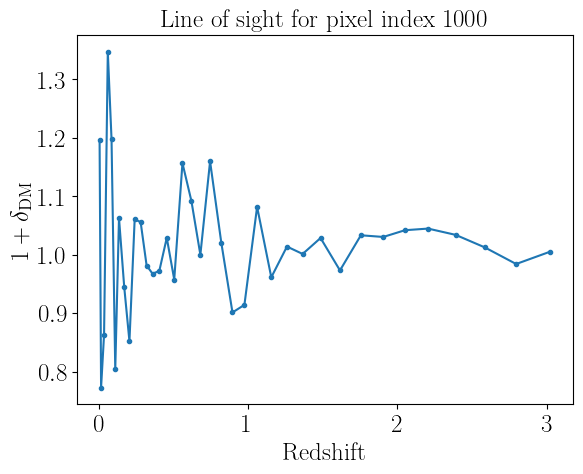

In [54]:
# plot the 1 + delta quantity for a given line of sight (i.e. a given pixel) as a function of redshift
pixel_index = 1000
plt.plot(zmean_vec, icaro_df[pixel_index], marker='.', color='tab:blue')
plt.xlabel(r'\rm Redshift')
plt.ylabel(r'\rm $1 + \delta_{\rm DM}$')
plt.title(rf'\rm Line of sight for pixel index {pixel_index}')
plt.show()